# Full Fine-Tuning - Native PyTorch
## Bangla-Hindi-English Code-Switched Sentiment Analysis

| File | Used for |
|------|----------|
| `train_cleaned.csv` | Training (30k synthetic samples) |
| `val_cleaned.csv` | Validation during training (10k) |
| `test_cleaned.csv` | Secondary evaluation (10k) |
| `sentmix_cleaned.csv` | Primary evaluation (1,007 tweets) |

| | |
|---|---|
| Base model | `xlm-roberta-base` (278M params, **all trainable**) |
| Approach | Full Fine-Tuning — trains 100% of parameters |

In [ ]:
#Install dependencies
!pip install transformers scikit-learn torch seaborn matplotlib -q

In [ ]:
#Imports and config

import os, json, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

CONFIG = {
    "model_name":    "xlm-roberta-base",
    "max_length":    128,
    "batch_size":    32,
    "num_epochs":    5,
    "learning_rate": 2e-5,
    "weight_decay":  0.01,
    "warmup_pct":    0.1,
    "max_grad_norm": 1.0,
    "patience":      2,
    "train_path":        "train_cleaned.csv",
    "val_path":          "val_cleaned.csv",
    "test_synth_path":   "test_cleaned.csv",
    "test_natural_path": "sentmix_cleaned.csv",
}

LABEL2ID = {"Positive": 0, "Negative": 1, "Neutral": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

Device: cuda


In [ ]:
# load pre-processed datasets
train_df   = pd.read_csv(CONFIG["train_path"])
val_df     = pd.read_csv(CONFIG["val_path"])
test_synth = pd.read_csv(CONFIG["test_synth_path"])
test_nat   = pd.read_csv(CONFIG["test_natural_path"])

print(f"  Train            : {len(train_df):>6,}  {dict(Counter(train_df['label']))}")
print(f"  Val              : {len(val_df):>6,}  {dict(Counter(val_df['label']))}")
print(f"  Test (synthetic) : {len(test_synth):>6,}  {dict(Counter(test_synth['label']))}")
print(f"  Test (SentMix-3L): {len(test_nat):>6,}  {dict(Counter(test_nat['label']))}")
print()
train_df.head(3)

  Train            : 29,994  {'Negative': 9999, 'Neutral': 9999, 'Positive': 9996}
  Val              :  9,998  {'Neutral': 3333, 'Negative': 3332, 'Positive': 3333}
  Test (synthetic) : 10,000  {'Neutral': 3333, 'Negative': 3333, 'Positive': 3334}
  Test (SentMix-3L):  1,007  {'Positive': 420, 'Neutral': 234, 'Negative': 353}



,clean_text,label,label_id
0,The description reads যে প্রোগ্রাম उपयोगकर्ता ...,Negative,1
1,Procite 5 একটি ব্যক্তিগত ডেটা বেস সংগঠিত করার ...,Neutral,2
2,मुझे यह मेरे बेटे के लिए एक छोटे जलरोधक वीडियो...,Neutral,2


In [ ]:
# Tokenization

print(f"Loading tokenizer: {CONFIG['model_name']} ...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

demo = "আজকের দিনটা khub bhalo ছিল, I am so happy today!"
tokens = tokenizer.tokenize(demo)
print(f"\nDemo  : {demo}")
print(f"Tokens: {tokens}")
print(f"Count : {len(tokens)}")

Loading tokenizer: xlm-roberta-base ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Demo  : আজকের দিনটা khub bhalo ছিল, I am so happy today!
Tokens: ['▁আজকের', '▁দিন', 'টা', '▁khu', 'b', '▁bha', 'lo', '▁ছিল', ',', '▁I', '▁am', '▁so', '▁happy', '▁today', '!']
Count : 15


In [ ]:
# PyTorch Dataset and DataLoaders

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }


def make_dataset(df):
    return SentimentDataset(
        texts=df["clean_text"].tolist(),
        labels=df["label_id"].tolist(),
        tokenizer=tokenizer,
        max_length=CONFIG["max_length"],
    )


def to_torch_dataloader(df_, shuffle=False):
    return DataLoader(
        make_dataset(df_),
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True,
    )


print("Building PyTorch DataLoaders ...")
train_loader      = to_torch_dataloader(train_df, shuffle=True)
val_loader        = to_torch_dataloader(val_df)
test_synth_loader = to_torch_dataloader(test_synth)
test_nat_loader   = to_torch_dataloader(test_nat)

print(f"  train_loader      : {len(train_df):,} samples")
print(f"  val_loader        : {len(val_df):,} samples")
print(f"  test_synth_loader : {len(test_synth):,} samples")
print(f"  test_nat_loader   : {len(test_nat):,} samples")

Building PyTorch DataLoaders ...
  train_loader      : 29,994 samples
  val_loader        : 9,998 samples
  test_synth_loader : 10,000 samples
  test_nat_loader   : 1,007 samples


# Full Fine-Tuning
With LoRA, we froze the entire pretrained model and only trained small adapter matrices we plugged in, but here we unlock everything and let the model update all of its weights during training

- All 12 transformer layers, the full embedding table (250k words × 768 dimensions), and the classification head are all learning from code-switched data

- Roughly 278 million parameters being adjusted, compared to just 887 thousand with LoRA

- The disadvantage is that, it can forget what it already knew about other languages, also known as catastrophic forgetting

- It also takes more GPU memory and time, so we need to be more careful with the learning rate, if it is too high then it destroys the useful knowledge from pre-training


In [ ]:
# build full fine-tuning model

print(f"Loading {CONFIG['model_name']} ...")
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
pct              = 100.0 * trainable_params / total_params

print("─" * 55)
print("  Full Fine-Tuning Parameter Breakdown")
print("─" * 55)
print(f"  Total parameters       : {total_params:>12,}")
print(f"  Trainable (all)        : {trainable_params:>12,}  ({pct:.1f}%)")
print(f"  Frozen                 : {frozen_params:>12,}  (none — full FT)")
print("─" * 55)
print(f"  Base model             : {CONFIG['model_name']}")
print(f"  Classifier head        : 768 → {NUM_LABELS}  (added)")
print("─" * 55)

Loading xlm-roberta-base ...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


───────────────────────────────────────────────────────
  Full Fine-Tuning Parameter Breakdown
───────────────────────────────────────────────────────
  Total parameters       :  278,045,955
  Trainable (all)        :  278,045,955  (100.0%)
  Frozen                 :            0  (none — full FT)
───────────────────────────────────────────────────────
  Base model             : xlm-roberta-base
  Classifier head        : 768 → 3  (added)
───────────────────────────────────────────────────────


In [ ]:
# training setup

total_steps  = len(train_loader) * CONFIG["num_epochs"]
no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

optimizer_grouped_params = [
    {
        "params": [
            p for n, p in model.named_parameters()
            if not any(nd in n for nd in no_decay) and "classifier" not in n
        ],
        "lr": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
    },
    {
        "params": [
            p for n, p in model.named_parameters()
            if any(nd in n for nd in no_decay) and "classifier" not in n
        ],
        "lr": CONFIG["learning_rate"],
        "weight_decay": 0.0,
    },
    {
        "params": [
            p for n, p in model.named_parameters()
            if "classifier" in n
        ],
        "lr": CONFIG["learning_rate"] * 5,
        "weight_decay": CONFIG["weight_decay"],
    },
]

optimizer = AdamW(optimizer_grouped_params)

scheduler = OneCycleLR(
    optimizer,
    max_lr=[CONFIG["learning_rate"], CONFIG["learning_rate"], CONFIG["learning_rate"] * 5],
    total_steps=total_steps,
    pct_start=CONFIG["warmup_pct"],
    anneal_strategy="cos",
)

criterion = nn.CrossEntropyLoss()

# Mixed precision scaler
use_amp = torch.cuda.is_available()
scaler  = torch.amp.GradScaler(enabled=use_amp)

print(f"Steps per epoch : {len(train_loader):,}")
print(f"Total steps     : {total_steps:,}")
print(f"Warmup steps    : {int(total_steps * CONFIG['warmup_pct']):,}")
print(f"Trainable params: {trainable_params:,} ({pct:.1f}% of total)")

Steps per epoch : 938
Total steps     : 4,690
Warmup steps    : 469
Trainable params: 278,045,955 (100.0% of total)


In [ ]:
# training loop

def train_epoch(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss    = criterion(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1  = f1_score(all_labels, all_preds, average="weighted")
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), f1, acc, all_preds, all_labels


# Training loop with early stopping
import warnings
warnings.filterwarnings("ignore")

print(f"Training on {len(train_df):,} samples for up to {CONFIG['num_epochs']} epochs")
print(f"Batch size : {CONFIG['batch_size']}  |  Steps/epoch : {len(train_loader):,}\n")

best_val_f1    = 0
patience_count = 0
best_state     = None
history        = []

t0 = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, scaler)
    val_loss, val_f1, val_acc, _, _ = eval_epoch(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_f1": val_f1,
        "val_acc": val_acc
    })

    print(f"Epoch {epoch}/{CONFIG['num_epochs']} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= CONFIG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}")
            break

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

# Restore best weights
model.load_state_dict(best_state)
model = model.to(device)

Training on 29,994 samples for up to 5 epochs
Batch size : 32  |  Steps/epoch : 938

Epoch 1/5 | Train Loss: 0.8301 | Val Loss: 0.6887 | Val F1: 0.6993 | Val Acc: 0.6973
Epoch 2/5 | Train Loss: 0.6306 | Val Loss: 0.6389 | Val F1: 0.7265 | Val Acc: 0.7225
Epoch 3/5 | Train Loss: 0.5236 | Val Loss: 0.6441 | Val F1: 0.7361 | Val Acc: 0.7366
Epoch 4/5 | Train Loss: 0.4290 | Val Loss: 0.7256 | Val F1: 0.7304 | Val Acc: 0.7322
Epoch 5/5 | Train Loss: 0.3695 | Val Loss: 0.7644 | Val F1: 0.7335 | Val Acc: 0.7336

Early stopping at epoch 5

Training complete in 1365.2s (22.8 min)


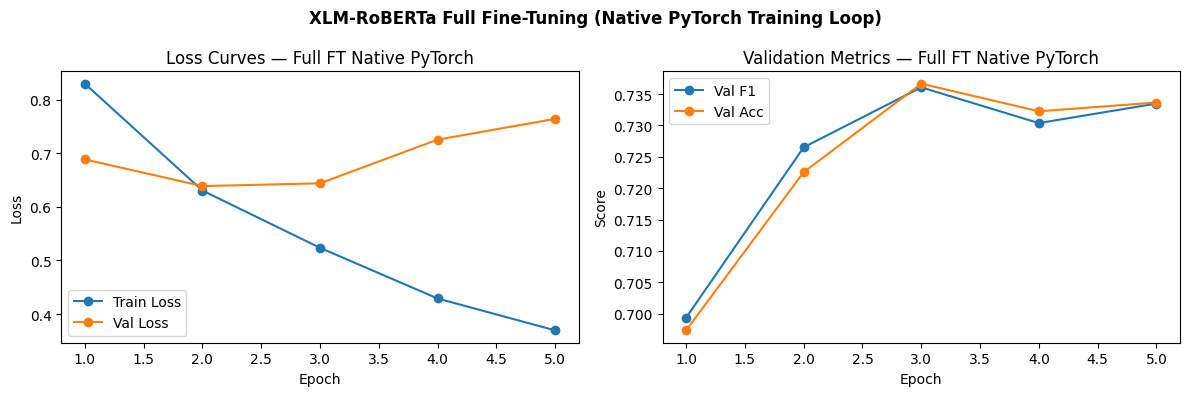

In [ ]:
# plot training curves

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", marker="o")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves — Full FT Native PyTorch")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["val_f1"],  label="Val F1",  marker="o")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="Val Acc", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation Metrics — Full FT Native PyTorch")
axes[1].legend()

plt.suptitle("XLM-RoBERTa Full Fine-Tuning (Native PyTorch Training Loop)", fontweight="bold")
plt.tight_layout()
plt.show()


── Synthetic Test Set ──────────────────────────
              precision    recall  f1-score   support

    Positive     0.8047    0.8146    0.8097      3334
    Negative     0.7491    0.7624    0.7557      3333
     Neutral     0.6427    0.6235    0.6330      3333

    accuracy                         0.7335     10000
   macro avg     0.7322    0.7335    0.7328     10000
weighted avg     0.7322    0.7335    0.7328     10000



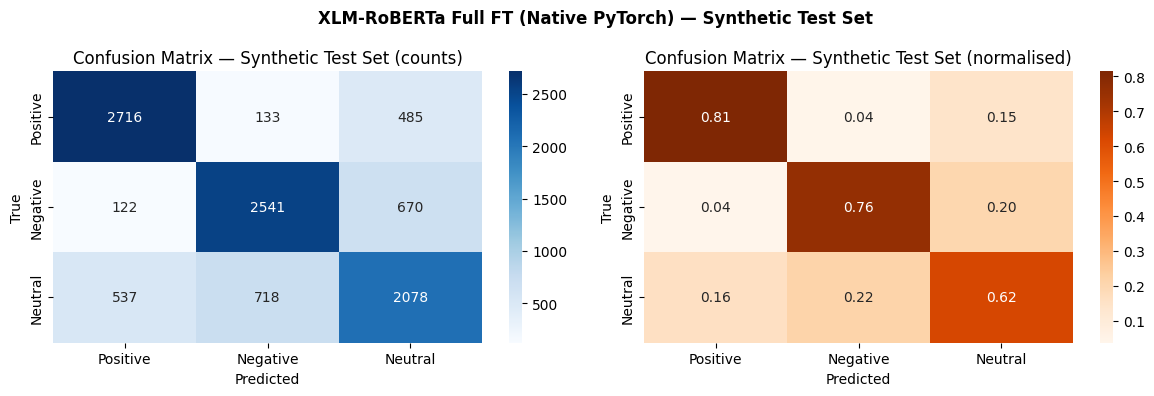


── SentMix-3L Natural Test Set ──────────────────────────
              precision    recall  f1-score   support

    Positive     0.6065    0.9833    0.7502       420
    Negative     0.9251    0.4901    0.6407       353
     Neutral     0.3237    0.1923    0.2413       234

    accuracy                         0.6266      1007
   macro avg     0.6184    0.5552    0.5441      1007
weighted avg     0.6525    0.6266    0.5936      1007



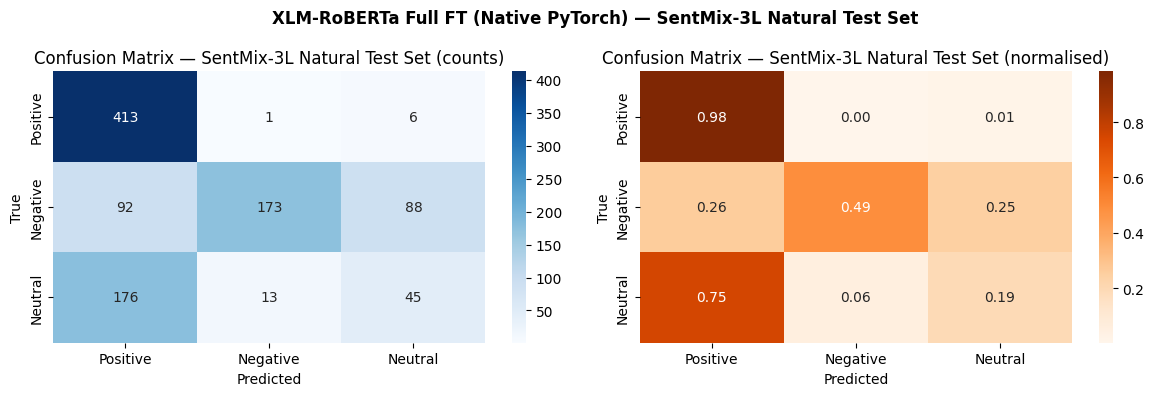

In [ ]:
# evaluation

def full_evaluate(loader, name):
    _, f1, acc, preds, labels = eval_epoch(model, loader)

    print(f"\n── {name} ──────────────────────────")
    print(classification_report(labels, preds,
          target_names=list(LABEL2ID.keys()), digits=4))

    report = classification_report(labels, preds,
             target_names=list(LABEL2ID.keys()),
             digits=4, output_dict=True)

    cm = confusion_matrix(labels, preds)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(LABEL2ID.keys()),
                yticklabels=list(LABEL2ID.keys()), ax=axes[0])
    axes[0].set_title(f"Confusion Matrix — {name} (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
                xticklabels=list(LABEL2ID.keys()),
                yticklabels=list(LABEL2ID.keys()), ax=axes[1])
    axes[1].set_title(f"Confusion Matrix — {name} (normalised)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    plt.suptitle(f"XLM-RoBERTa Full FT (Native PyTorch) — {name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return report

report_synth = full_evaluate(test_synth_loader, "Synthetic Test Set")
report_nat   = full_evaluate(test_nat_loader,   "SentMix-3L Natural Test Set")

In [ ]:
# results summary

wf1_s   = report_synth["weighted avg"]["f1-score"]
mf1_s   = report_synth["macro avg"]["f1-score"]
acc_s   = report_synth["accuracy"]
wf1_nat = report_nat["weighted avg"]["f1-score"]
mf1_nat = report_nat["macro avg"]["f1-score"]
acc_nat = report_nat["accuracy"]

print("=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Model              : {CONFIG['model_name']}")
print(f"  Framework          : Native PyTorch (no Trainer API)")
print(f"  Approach           : Full Fine-Tuning")
print()
print("  ── Parameters ───────────────────────────────────────────")
print(f"  Total params       : {total_params:>12,}")
print(f"  Trainable (all)    : {trainable_params:>12,}  ({pct:.1f}%)")
print(f"  Frozen             : {frozen_params:>12,}")
print()
print("  ── Training ─────────────────────────────────────────────")
print(f"  Training time      : {elapsed:.1f}s  ({elapsed/60:.1f} min)")
print(f"  Epochs run         : {len(history)}")
print(f"  Batch size         : {CONFIG['batch_size']}")
print(f"  Learning rate      : {CONFIG['learning_rate']}")
print(f"  Optimizer          : AdamW (PyTorch)")
print(f"  Scheduler          : OneCycleLR")
print()
print("  ── Primary: Synthetic Test Set ──────────────────────────")
print(f"  Weighted F1        : {wf1_s:.4f}")
print(f"  Macro F1           : {mf1_s:.4f}")
print(f"  Accuracy           : {acc_s:.4f}")
print()
print("  ── Secondary: SentMix-3L Natural Test Set ───────────────")
print(f"  Weighted F1        : {wf1_nat:.4f}")
print(f"  Macro F1           : {mf1_nat:.4f}")
print(f"  Accuracy           : {acc_nat:.4f}")
print("=" * 60)

summary = {
    "model": CONFIG["model_name"],
    "framework": "Native PyTorch (no Trainer API)",
    "approach": "full_fine_tuning",
    "params": {"total": total_params, "trainable": trainable_params,
               "frozen": frozen_params,
               "trainable_pct": round(pct, 4)},
    "training": {"epochs_run": len(history), "time_sec": round(elapsed, 2),
                 "lr": CONFIG["learning_rate"],
                 "batch_size": CONFIG["batch_size"],
                 "optimizer": "AdamW (PyTorch)",
                 "scheduler": "OneCycleLR"},
    "primary_test_synthetic": {
        "weighted_f1": round(wf1_s, 4),
        "macro_f1":    round(mf1_s, 4),
        "accuracy":    round(acc_s, 4),
    },
    "secondary_test_sentmix3l": {
        "weighted_f1": round(wf1_nat, 4),
        "macro_f1":    round(mf1_nat, 4),
        "accuracy":    round(acc_nat, 4),
    },
    "training_history": history,
}
with open("full_ft_pytorch_results.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved → full_ft_pytorch_results.json ✓")

  FINAL RESULTS SUMMARY
  Model              : xlm-roberta-base
  Framework          : Native PyTorch (no Trainer API)
  Approach           : Full Fine-Tuning

  ── Parameters ───────────────────────────────────────────
  Total params       :  278,045,955
  Trainable (all)    :  278,045,955  (100.0%)
  Frozen             :            0

  ── Training ─────────────────────────────────────────────
  Training time      : 1365.2s  (22.8 min)
  Epochs run         : 5
  Batch size         : 32
  Learning rate      : 2e-05
  Optimizer          : AdamW (PyTorch)
  Scheduler          : OneCycleLR

  ── Primary: Synthetic Test Set ──────────────────────────
  Weighted F1        : 0.7328
  Macro F1           : 0.7328
  Accuracy           : 0.7335

  ── Secondary: SentMix-3L Natural Test Set ───────────────
  Weighted F1        : 0.5936
  Macro F1           : 0.5441
  Accuracy           : 0.6266

Saved → full_ft_pytorch_results.json ✓


In [ ]:
# inference demo

import re, unicodedata

DEMO_SENTENCES = [
    ("আজকের দিনটা khub bhalo ছিল, I am so happy today!",          "Positive"),
    ("Aaj main bahut khush hoon কারণ আমার result ভালো হয়েছে!",   "Positive"),
    ("यह फिल्म একদম bakwas ছিল, worst movie I have ever seen.",    "Negative"),
    ("দিনটা বাজে গেছে, sab kuch galat ho gaya today.",              "Negative"),
    ("আবহাওয়া আজ theek hai, kuch khaas nahi.",                     "Neutral"),
    ("Main office গেছি, কাজ শেষ করলাম, ghar wapis aa gaya.",      "Neutral"),
]

def quick_clean(text):
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|@\w+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

model.eval()
print("─" * 70)
print(f"{'Input (truncated)':<44} {'True':>10} {'Pred':>10} {'Conf':>7}")
print("─" * 70)

for text, true_label in DEMO_SENTENCES:
    clean = quick_clean(text)
    enc   = tokenizer(clean, return_tensors="pt", truncation=True,
                      max_length=CONFIG["max_length"], padding=True)
    enc   = {k: v.to(device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
    probs   = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    conf    = probs.max().item()
    match   = "✓" if ID2LABEL[pred_id] == true_label else "✗"
    print(f"{match} {text[:42]:<42} {true_label:>10} {ID2LABEL[pred_id]:>10} {conf:>6.1%}")

print("─" * 70)

──────────────────────────────────────────────────────────────────────
Input (truncated)                                  True       Pred    Conf
──────────────────────────────────────────────────────────────────────
✓ আজকের দিনটা khub bhalo ছিল, I am so happy    Positive   Positive  96.9%
✓ Aaj main bahut khush hoon কারণ আমার result   Positive   Positive  93.0%
✓ यह फिल्म একদম bakwas ছিল, worst movie I ha   Negative   Negative  99.4%
✗ দিনটা বাজে গেছে, sab kuch galat ho gaya to   Negative    Neutral  56.5%
✓ আবহাওয়া আজ theek hai, kuch khaas nahi.       Neutral    Neutral  83.0%
✗ Main office গেছি, কাজ শেষ করলাম, ghar wapi    Neutral   Negative  40.2%
──────────────────────────────────────────────────────────────────────


In [ ]:
# save model

SAVE_PATH = "/content/full_ft_pytorch_model"
os.makedirs(SAVE_PATH, exist_ok=True)
torch.save(model.state_dict(), f"{SAVE_PATH}/model_weights.pt")
tokenizer.save_pretrained(SAVE_PATH)

size_mb = sum(
    os.path.getsize(os.path.join(SAVE_PATH, f))
    for f in os.listdir(SAVE_PATH)
) / 1e6

print(f"Model saved : {SAVE_PATH}")
print(f"Model size  : {size_mb:.1f} MB")

Model saved : /content/full_ft_pytorch_model
Model size  : 1129.1 MB
